In [31]:
import pandas as pd
df = pd.read_csv("data/Salary_Data.csv")
df.head()
df.tail()
df.shape
df.info()
df.columns
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   str    
 2   Education Level      6701 non-null   str    
 3   Job Title            6702 non-null   str    
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), str(3)
memory usage: 314.4 KB


,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [32]:
import numpy as np
df['Age']=df['Age'].fillna(df['Age'].median())
df.isnull().sum()
df['Gender']=df['Gender'].replace(['Unknown'], np.nan)
# df['Gender']=df['Gender'].fillna(df['Gender'].mean())
df['Gender']=df['Gender'].fillna('Unknown')
df = df.dropna(subset=['Salary'])
df['Education Level']=df['Education Level'].fillna('Not provided')
df['Job Title']=df['Job Title'].fillna('Not provided')
df['Years of Experience'] = pd.to_numeric(df['Years of Experience'], errors='coerce').fillna(df['Years of Experience'].apply(pd.to_numeric, errors='coerce').median())
df.isnull().sum()


Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(4911)

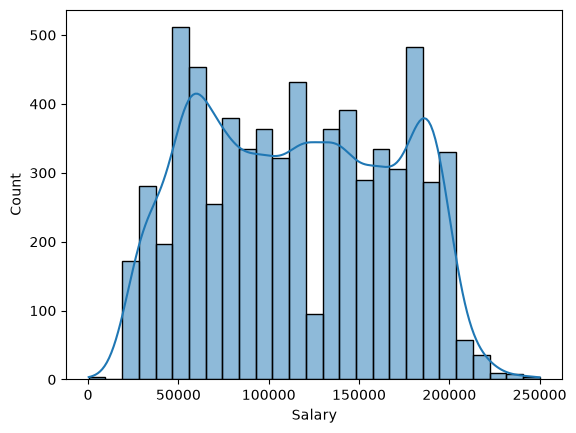

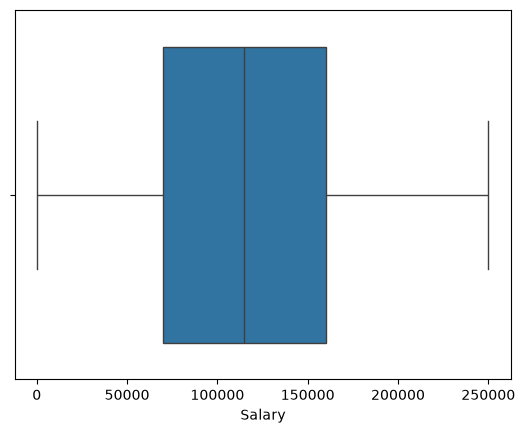

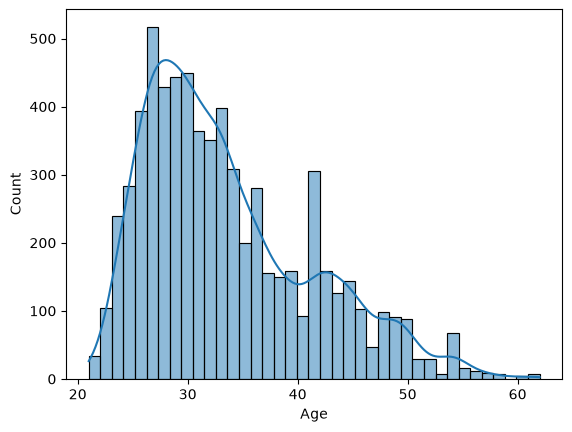

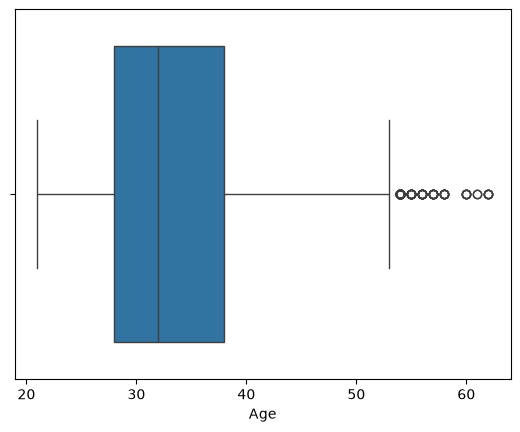

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(x=df['Salary'], kde=True)
plt.show()
sns.boxplot(x=df['Salary'])
plt.show()
sns.histplot(x=df['Age'], kde=True)
plt.show()  
sns.boxplot(x=df['Age'])
plt.show()

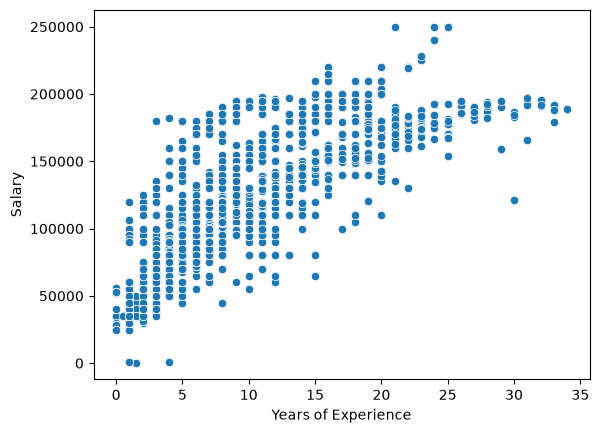

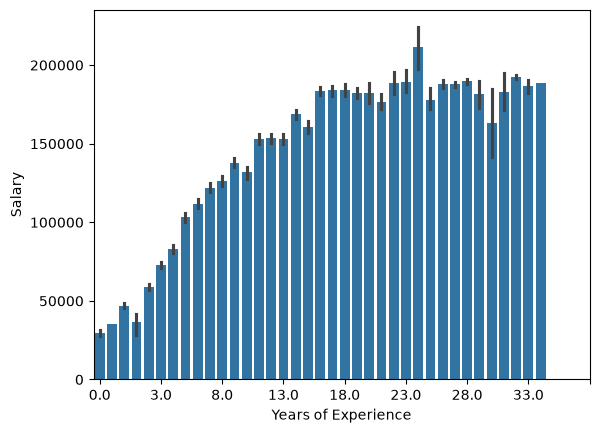

In [35]:
sns.scatterplot(x='Years of Experience', y='Salary', data=df)
plt.show()
sns.barplot(x='Years of Experience', y='Salary', data=df)
plt.xticks(ticks=range(0, 41, 5))
plt.show()

In [36]:

df['Education Level'].unique()                                              
df['Job Title'].unique()


from sklearn.preprocessing import LabelEncoder
Encode = LabelEncoder()
df['Education Level'] = pd.Series(Encode.fit_transform(df['Education Level']), index=df.index)
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)
df = pd.get_dummies(df, columns=['Job Title'], drop_first=True)
X = df.drop('Salary', axis=1)
y = df['Salary']
print(X.select_dtypes(include='object').columns)



Index([], dtype='str')


In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)

# Scale testing data using SAME mean & std
X_test = scaler.transform(X_test)




In [41]:

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train) 
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error (y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R2):", r2)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))



Mean Absolute Error (MAE): 15564.05851208957
Mean Squared Error (MSE): 453802549.1626192
R-squared (R2): 0.840376645833928


ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [39]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='str')


In [40]:
df.info()
X = df.drop('Salary', axis=1)
y = df['Salary']

<class 'pandas.DataFrame'>
Index: 6699 entries, 0 to 6703
Columns: 197 entries, Age to Job Title_Web Developer
dtypes: bool(193), float64(3), int64(1)
memory usage: 1.5 MB
